# Non-Invasive BGL Estimation: Window-Based Data Augmentation & Feature Analysis
**GlucoSense Primary Dataset (Nigerian T2DM Cohort)**  
*Author: FYP Research Team | Healthcare AI & Biomedical Signal Processing*

---

## 📌 Notebook Objectives & Architecture
1. **Raw Dataset Integrity**: Load original session CSV (`df_raw`) directly without modification.
2. **Configurable Window Segmentation**: Divide 60s active PPG signals into sub-windows (default: **30-second non-overlapping windows**, $2\times$ data expansion).
3. **Structured Feature Hierarchy**: Categorize all extracted features into explicit group registries (Demographics, AC/DC Perfusion, Waveform Morphology, APG Derivatives, HRV).
4. **Single-Window Interactive Inspector**: Easily view all extracted features for any individual window sample.
5. **Dataset-Wide Correlation Analysis**: Benchmark Pearson $r$ and Spearman $\rho$ correlations against $y$ (`bgl_mgdl`) prior to cross-validation.
6. **Zero-Leakage Grouped Cross-Validation**: Evaluate Random Forest, CatBoost, XGBoost, and Ridge using `GroupKFold` and `LOGOCV` strictly grouped by `participant_id` (preventing participant data leakage).


In [27]:
# ── System Imports & Style Configuration ──
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
from scipy.stats import skew, kurtosis, pearsonr, spearmanr, entropy
from scipy.interpolate import interp1d
from collections import Counter

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import KFold, GroupKFold, LeaveOneOut, LeaveOneGroupOut, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

try:
    import catboost as cb
    has_catboost = True
except ImportError:
    has_catboost = False

try:
    import lightgbm as lgb
    has_lightgbm = True
except ImportError:
    has_lightgbm = False

try:
    import xgboost as xgb
    has_xgboost = True
except ImportError:
    has_xgboost = False

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

RAW_CSV_PATH = 'data/real/glucosense_r_dataset_2026-09-17.csv'
SAMPLING_RATE = 50

print(f"✓ Environment ready. CatBoost: {has_catboost}, LightGBM: {has_lightgbm}, XGBoost: {has_xgboost}.")


✓ Environment ready. CatBoost: True, LightGBM: True, XGBoost: True.


In [28]:
# ── Load Original Raw Dataset (df_raw) ──
if not os.path.exists(RAW_CSV_PATH):
    raise FileNotFoundError(f"Raw dataset CSV not found at {RAW_CSV_PATH}")

df_raw = pd.read_csv(RAW_CSV_PATH)

print(f"✓ Loaded Original Raw Dataset (df_raw): {len(df_raw)} total recording sessions.")
print(f"✓ Unique Participants: {df_raw['participant_id'].nunique()}")
print("\nFirst 3 rows of df_raw:")
display(df_raw.head(3))

print("\nSession Kind Distribution (df_raw):")
print(df_raw['session_kind'].value_counts())


✓ Loaded Original Raw Dataset (df_raw): 100 total recording sessions.
✓ Unique Participants: 88

First 3 rows of df_raw:


,session_id,created_at,participant_id,age,gender,weight_kg,height_cm,years_on_t2dm,medication,session_kind,bgl_mgdl,ppg_samples_count,ppg_data
0,fce4b7a2-b3db-4b11-81e7-9c8f8ace228d,2026-08-06T09:03:50.335985+00:00,P001,73,Female,74.0,170.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",fasting,196,3500,57994;58030;58020;58027;58013;58039;58044;5805...
1,07dc95d8-8001-417f-b139-d4faf092b371,2026-08-06T10:34:31.431381+00:00,P001,73,Female,74.0,170.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",1hr_post_prandial,269,3500,59419;59453;59470;59475;59513;59507;59529;5956...
2,2fb9eb9e-4f36-4749-bb66-78510db5dde9,2026-08-27T07:56:02.871753+00:00,P002,63,Female,79.0,172.0,21,NaN,fasting,190,3500,55490;55479;55469;55480;55473;55469;55476;5548...



Session Kind Distribution (df_raw):
session_kind
fasting              46
2hr_post_prandial    31
1hr_post_prandial    23
Name: count, dtype: int64


In [29]:
# ==========================================
# WINDOWING & SIGNAL PROCESSING CONFIGURATION
# ==========================================
STABILIZATION_SEC = 10  # Initial 10s stabilization phase to discard
WINDOW_SEC        = 30  # Window duration in seconds (e.g. 30s or 20s)
OVERLAP_SEC       = 0   # Overlap in seconds (0s for non-overlapping)
MIN_HEART_RATE    = 60.0 # Minimum physiological Heart Rate threshold (BPM)
MAX_BGL           = 300.0 # Maximum BGL threshold for target outlier filtering (mg/dL)

print(f"✓ Window Configuration: WINDOW_SEC = {WINDOW_SEC}s | OVERLAP_SEC = {OVERLAP_SEC}s | STABILIZATION_SEC = {STABILIZATION_SEC}s")
print(f"✓ Signal Thresholds: MIN_HEART_RATE = {MIN_HEART_RATE} BPM | MAX_BGL = {MAX_BGL} mg/dL")

def determine_ac_dc_from_PPG(signal):
    signal = np.asarray(signal, dtype=np.float64)
    if len(signal) == 0:
        return 0.0, 0.0, 0.0
    max_array, min_array = [], []
    mid_value = float(np.mean(signal))
    max_value, min_value = mid_value, mid_value
    max_index, min_index = 0, 0
    for i in range(len(signal)):
        now_value = signal[i]
        if now_value > mid_value:
            if min_value < mid_value and min_index > 0:
                min_array.append(min_value)
                min_value = mid_value
            if now_value > max_value:
                max_value = now_value
                max_index = i
        if now_value < mid_value:
            if maxValue > mid_value and max_index > 0 if 'maxValue' in locals() else (max_value > mid_value and max_index > 0):
                max_array.append(max_value)
                max_value = mid_value
            if now_value < min_value:
                min_value = now_value
                min_index = i
    ac_signal = float(np.mean(max_array) - np.mean(min_array)) if (len(max_array) > 0 and len(min_array) > 0) else 0.0
    dc_signal = mid_value
    ac_dc_ratio = float(ac_signal / (dc_signal + 1e-9)) if dc_signal != 0 else 0.0
    return ac_signal, dc_signal, ac_dc_ratio

def extract_pulse_morphology_features(avg_beat):
    peak_val = float(np.max(avg_beat))
    trough_val = float(np.min(avg_beat))
    peak_to_peak = peak_val - trough_val
    mean_val = float(np.mean(avg_beat))
    std_val = float(np.std(avg_beat))
    rms_val = float(np.sqrt(np.mean(avg_beat**2)))
    skew_val = float(skew(avg_beat))
    kurt_val = float(kurtosis(avg_beat))
    crest_factor = float(peak_val / (rms_val + 1e-5))
    impulse_factor = float(peak_val / (mean_val + 1e-5))
    median_diff = float(np.median(np.abs(np.diff(avg_beat))))
    slope = float(np.max(np.gradient(avg_beat)))
    fft_vals = np.abs(np.fft.rfft(avg_beat))**2
    psd_norm = fft_vals / (np.sum(fft_vals) + 1e-8)
    spec_entropy = float(entropy(psd_norm + 1e-12, base=2))
    raw_dict = {
        'peak_val': peak_val, 'peak_to_peak': peak_to_peak, 'mean_val': mean_val,
        'std_val': std_val, 'rms_val': rms_val, 'skewness': skew_val, 'kurtosis': kurt_val,
        'crest_factor': crest_factor, 'impulse_factor': impulse_factor,
        'median_diff': median_diff, 'slope': slope, 'spectral_entropy': spec_entropy
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}

def extract_apg_landmarks(avg_beat):
    vpg = np.gradient(avg_beat)
    apg = np.gradient(vpg)
    len_b = len(avg_beat)
    a_idx = np.argmax(apg[:int(len_b * 0.35)])
    a_val = apg[a_idx] if apg[a_idx] > 0 else 1e-5
    search_b_end = int(len_b * 0.5)
    b_val = apg[a_idx + np.argmin(apg[a_idx:search_b_end])] if search_b_end > a_idx + 2 else 0.0
    b_idx = a_idx + np.argmin(apg[a_idx:search_b_end]) if search_b_end > a_idx + 2 else a_idx
    search_c_end = int(len_b * 0.65)
    c_val = apg[b_idx + np.argmax(apg[b_idx:search_c_end])] if search_c_end > b_idx + 1 else 0.0
    c_idx = b_idx + np.argmax(apg[b_idx:search_c_end]) if search_c_end > b_idx + 1 else b_idx
    search_d_end = int(len_b * 0.8)
    d_val = apg[c_idx + np.argmin(apg[c_idx:search_d_end])] if search_d_end > c_idx + 1 else 0.0
    d_idx = c_idx + np.argmin(apg[c_idx:search_d_end]) if search_d_end > c_idx + 1 else c_idx
    e_val = apg[d_idx + np.argmax(apg[d_idx:])] if len_b > d_idx + 1 else 0.0
    b_a = b_val / a_val
    c_a = c_val / a_val
    d_a = d_val / a_val
    e_a = e_val / a_val
    aging_index = (b_val - c_val - d_val - e_val) / a_val
    elasticity_index = (b_val - c_val - d_val) / a_val
    deceleration_index = (d_val - e_val) / a_val
    raw_dict = {
        'apg_a': a_val, 'apg_b': b_val, 'apg_c': c_val, 'apg_d': d_val, 'apg_e': e_val,
        'b_a_ratio': b_a, 'c_a_ratio': c_a, 'd_a_ratio': d_a, 'e_a_ratio': e_a,
        'aging_index': aging_index, 'elasticity_index': elasticity_index, 'deceleration_index': deceleration_index
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}

def process_subwindow_signal(ppg_subwin, sr=50):
    cleaned = nk.ppg_clean(ppg_subwin, sampling_rate=sr, method='elgendi')
    signals, info = nk.ppg_process(cleaned, sampling_rate=sr, method='elgendi')
    peaks = info['PPG_Peaks']
    hrv_df = nk.ppg_analyze(signals, sampling_rate=sr)
    if 'PPG_Rate' in signals.columns and not pd.isna(signals['PPG_Rate'].mean()):
        heart_rate = float(signals['PPG_Rate'].mean())
    elif 'PPG_Rate_Mean' in hrv_df.columns and not pd.isna(hrv_df['PPG_Rate_Mean'].values[0]):
        heart_rate = float(hrv_df['PPG_Rate_Mean'].values[0])
    elif len(peaks) >= 2:
        heart_rate = float(60.0 / np.mean(np.diff(peaks) / sr))
    else:
        heart_rate = 0.0
    troughs = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 > 10:
            troughs.append(p1 + np.argmin(cleaned[p1:p2]))
    valid_beats = []
    target_len = 100
    for i in range(len(troughs) - 1):
        t1, t2 = troughs[i], troughs[i+1]
        beat_len = t2 - t1
        if 18 <= beat_len <= 80:
            beat = cleaned[t1:t2]
            x_old = np.linspace(0, 1, len(beat))
            x_new = np.linspace(0, 1, target_len)
            beat_resampled = interp1d(x_old, beat, kind='cubic')(x_new)
            b_min, b_max = beat_resampled.min(), beat_resampled.max()
            if b_max - b_min > 1e-5:
                valid_beats.append((beat_resampled - b_min) / (b_max - b_min))
    if len(valid_beats) < 2:
        avg_beat = np.zeros(target_len)
        num_valid_beats = 0
    else:
        valid_beats_arr = np.array(valid_beats)
        median_beat = np.median(valid_beats_arr, axis=0)
        corrs = [np.corrcoef(b, median_beat)[0, 1] for b in valid_beats_arr]
        clean_beats = [b for b, c in zip(valid_beats_arr, corrs) if c > 0.75]
        avg_beat = np.mean(clean_beats, axis=0) if len(clean_beats) >= 2 else median_beat
        num_valid_beats = len(clean_beats) if len(clean_beats) >= 2 else len(valid_beats)
    s_peak_idx = np.argmax(avg_beat)
    s_peak_val = avg_beat[s_peak_idx]
    d_peak_val = avg_beat[s_peak_idx + 5 + np.argmax(avg_beat[s_peak_idx+5:target_len-5])] if s_peak_idx + 5 < target_len - 10 else 0.0
    vpg_avg = np.gradient(avg_beat)
    apg_avg = np.gradient(vpg_avg)
    paper_ac, paper_dc, paper_ac_dc_ratio = determine_ac_dc_from_PPG(ppg_subwin)
    paper_log_ac_dc_ratio = float(np.log(np.maximum(paper_ac_dc_ratio, 1e-9)))
    try:
        nk_perf_series = nk.ppg_quality(cleaned, sampling_rate=sr, method='perfusion', ppg_raw=ppg_subwin)
        nk_perf_mean = float(np.mean(nk_perf_series))
        nk_perf_std = float(np.std(nk_perf_series))
        nk_perf_median = float(np.median(nk_perf_series))
    except Exception:
        nk_perf_mean = nk_perf_std = nk_perf_median = 0.0
    dc_component = float(np.mean(ppg_subwin))
    ac_pp_amp = float(np.max(cleaned) - np.min(cleaned))
    ac_std_val = float(np.std(cleaned))
    ac_dc_ratio_val = float(ac_pp_amp / (dc_component + 1e-9))
    ac_dc_ratio_std_val = float((2.0 * np.sqrt(2.0) * ac_std_val) / (dc_component + 1e-9))
    log_ac_dc_ratio_val = float(np.log(np.maximum(ac_dc_ratio_val, 1e-9)))
    feats = {
        'paper_ac_signal': paper_ac, 'paper_dc_signal': paper_dc,
        'paper_ac_dc_ratio': paper_ac_dc_ratio, 'paper_log_ac_dc_ratio': paper_log_ac_dc_ratio,
        'nk_perfusion_mean': nk_perf_mean, 'nk_perfusion_std': nk_perf_std, 'nk_perfusion_median': nk_perf_median,
        'dc_component': dc_component, 'ac_pp_amplitude': ac_pp_amp,
        'ac_dc_ratio': ac_dc_ratio_val, 'ac_dc_ratio_std': ac_dc_ratio_std_val, 'log_ac_dc_ratio': log_ac_dc_ratio_val,
        'computed_heart_rate': heart_rate, 'num_valid_beats': num_valid_beats,
        'avg_ppg_amp': s_peak_val, 'avg_ppg_skew': skew(avg_beat), 'avg_ppg_kurt': kurtosis(avg_beat),
        'avg_vpg_amp': np.max(vpg_avg) - np.min(vpg_avg), 'avg_vpg_max_upstroke': np.max(vpg_avg), 'avg_vpg_skew': skew(vpg_avg),
        'avg_apg_amp': np.max(apg_avg) - np.min(apg_avg), 'avg_apg_skew': skew(apg_avg),
        'reflection_index': d_peak_val / (s_peak_val + 1e-5)
    }
    feats.update(extract_pulse_morphology_features(avg_beat))
    feats.update(extract_apg_landmarks(avg_beat))
    for col in hrv_df.columns:
        val = hrv_df[col].values[0]
        if not pd.isna(val):
            feats[col] = val
    return feats, heart_rate


✓ Window Configuration: WINDOW_SEC = 30s | OVERLAP_SEC = 0s | STABILIZATION_SEC = 10s
✓ Signal Thresholds: MIN_HEART_RATE = 60.0 BPM | MAX_BGL = 300.0 mg/dL


In [30]:
# ── Extract Window-Segmented Dataset (df_windowed_features) ──
window_samples  = WINDOW_SEC * SAMPLING_RATE
step_samples    = (WINDOW_SEC - OVERLAP_SEC) * SAMPLING_RATE
stab_samples    = STABILIZATION_SEC * SAMPLING_RATE

windowed_rows = []
skipped_sessions = 0
skipped_high_bgl = 0
skipped_low_hr   = 0

print(f"Extracting features across windows... (Window={WINDOW_SEC}s, Step={step_samples/SAMPLING_RATE}s)")

for session_idx, row in df_raw.iterrows():
    bgl_raw = row.get('bgl_mgdl', np.nan)
    ppg_str = str(row.get('ppg_data', ''))
    if pd.isna(bgl_raw) or not ppg_str or ppg_str == 'nan':
        skipped_sessions += 1
        continue
    bgl_val = float(bgl_raw)
    if bgl_val > MAX_BGL:
        skipped_high_bgl += 1
        continue
    try:
        ppg_full = np.array([float(x) for x in ppg_str.split(';') if x.strip()])
        if len(ppg_full) < stab_samples + window_samples:
            skipped_sessions += 1
            continue
        active_signal = ppg_full[stab_samples:]
        win_idx = 0
        for start_pos in range(0, len(active_signal) - window_samples + 1, step_samples):
            sub_win = active_signal[start_pos : start_pos + window_samples]
            feats, hr_val = process_subwindow_signal(sub_win, sr=SAMPLING_RATE)
            if hr_val < MIN_HEART_RATE:
                skipped_low_hr += 1
                continue
            meta_row = {
                'session_id': row['session_id'],
                'participant_id': row['participant_id'],
                'session_kind': row['session_kind'],
                'window_index': win_idx,
                'age': row['age'],
                'gender': 1 if row['gender'] == 'Male' else 0,
                'weight_kg': row['weight_kg'],
                'height_cm': row['height_cm'],
                'years_on_t2dm': row['years_on_t2dm'],
                'is_postprandial': 0 if row['session_kind'] == 'fasting' else 1,
                'bgl_mgdl': bgl_val
            }
            meta_row.update(feats)
            windowed_rows.append(meta_row)
            win_idx += 1
    except Exception:
        skipped_sessions += 1
        continue

df_windowed_features = pd.DataFrame(windowed_rows)
print('='*65)
print('  WINDOWED DATASET AUGMENTATION SUMMARY')
print('='*65)
print(f'  Original Raw Dataset Sessions:           {len(df_raw)}')
print(f'  Skipped - Missing BGL or PPG Signal:     {skipped_sessions}')
print(f'  Skipped - High BGL Outliers (> {MAX_BGL}):     {skipped_high_bgl}')
print(f'  Skipped - Low Heart Rate Windows (< {MIN_HEART_RATE}): {skipped_low_hr}')
print(f'✓ EXTRACTED WINDOWED DATASET (df_windowed_features): {len(df_windowed_features)} Total Windows')
print(f'  Expansion Factor:                        {len(df_windowed_features) / (len(df_raw) - skipped_sessions - skipped_high_bgl):.2f}x')
print(f'  Features per Window:                     {df_windowed_features.shape[1]}')
print('='*65)


Extracting features across windows... (Window=30s, Step=30.0s)


  WINDOWED DATASET AUGMENTATION SUMMARY
  Original Raw Dataset Sessions:           100
  Skipped - Missing BGL or PPG Signal:     0
  Skipped - High BGL Outliers (> 300.0):     3
  Skipped - Low Heart Rate Windows (< 60.0): 3
✓ EXTRACTED WINDOWED DATASET (df_windowed_features): 191 Total Windows
  Expansion Factor:                        1.97x
  Features per Window:                     134


In [21]:
# ==========================================
# FEATURE CATEGORIZATION & GROUP REGISTRY
# ==========================================
all_cols = df_windowed_features.columns.tolist()

# Static patient metadata columns not eligible as direct ML model input features
PATIENT_METADATA_COLS = ['age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm']

# Non-feature identifiers & target column
non_feature_cols = ['session_id', 'participant_id', 'session_kind', 'window_index', 'bgl_mgdl'] + PATIENT_METADATA_COLS

# Only 'is_postprandial' is eligible as an input feature among demographic/metadata attributes
DEMOGRAPHIC_METADATA_COLS = ['is_postprandial']

AC_DC_PERFUSION_FEATURES = [
    'paper_ac_signal', 'paper_dc_signal', 'paper_ac_dc_ratio', 'paper_log_ac_dc_ratio',
    'nk_perfusion_mean', 'nk_perfusion_std', 'nk_perfusion_median',
    'dc_component', 'ac_pp_amplitude', 'ac_dc_ratio', 'ac_dc_ratio_std', 'log_ac_dc_ratio'
]
PPG_MORPHOLOGY_FEATURES = [
    'avg_ppg_amp', 'avg_ppg_skew', 'avg_ppg_kurt', 'peak_val', 'peak_to_peak', 'mean_val',
    'std_val', 'rms_val', 'skewness', 'kurtosis', 'crest_factor', 'impulse_factor',
    'median_diff', 'slope', 'spectral_entropy'
]
VPG_APG_DERIVATIVE_FEATURES = [
    'avg_vpg_amp', 'avg_vpg_max_upstroke', 'avg_vpg_skew', 'avg_apg_amp', 'avg_apg_skew',
    'reflection_index', 'apg_a', 'apg_b', 'apg_c', 'apg_d', 'apg_e', 'b_a_ratio', 'c_a_ratio',
    'd_a_ratio', 'e_a_ratio', 'aging_index', 'elasticity_index', 'deceleration_index'
]
known_group_cols = set(non_feature_cols + DEMOGRAPHIC_METADATA_COLS + AC_DC_PERFUSION_FEATURES + PPG_MORPHOLOGY_FEATURES + VPG_APG_DERIVATIVE_FEATURES)
HRV_TIME_FREQUENCY_FEATURES = [c for c in all_cols if c not in known_group_cols]
ALL_CANDIDATE_FEATURES = [c for c in all_cols if c not in non_feature_cols]

print('=== Feature Category Registry Summary ===')
print(f'  1. Eligible Demographic Feature (is_postprandial): {len(DEMOGRAPHIC_METADATA_COLS)}')
print(f'  2. AC/DC Perfusion Features:                     {len(AC_DC_PERFUSION_FEATURES)}')
print(f'  3. PPG Waveform Morphology:                     {len(PPG_MORPHOLOGY_FEATURES)}')
print(f'  4. VPG/APG Derivative Features:                  {len(VPG_APG_DERIVATIVE_FEATURES)}')
print(f'  5. HRV Time/Spectral Features:                   {len(HRV_TIME_FREQUENCY_FEATURES)}')
print(f'✓ TOTAL ELIGIBLE CANDIDATE FEATURE POOL:           {len(ALL_CANDIDATE_FEATURES)} features')
print(f'  (Excluded Ineligible Static Demographics:        {PATIENT_METADATA_COLS})')


=== Feature Category Registry Summary ===
  1. Eligible Demographic Feature (is_postprandial): 1
  2. AC/DC Perfusion Features:                     12
  3. PPG Waveform Morphology:                     15
  4. VPG/APG Derivative Features:                  18
  5. HRV Time/Spectral Features:                   78
✓ TOTAL ELIGIBLE CANDIDATE FEATURE POOL:           124 features
  (Excluded Ineligible Static Demographics:        ['age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm'])


In [31]:
# ── Interactive Single-Window Sample Inspection Helper ──
def inspect_sample_window(df_data, window_idx=0):
    if window_idx < 0 or window_idx >= len(df_data):
        print(f"Index {window_idx} out of range. Valid range: 0 to {len(df_data)-1}")
        return
    sample_row = df_data.iloc[window_idx]
    print("="*65)
    print(f"  SINGLE WINDOW INSPECTOR | Window Index: {window_idx}")
    print(f"  Participant: {sample_row['participant_id']} | Session: {sample_row['session_kind']} (Win #{sample_row['window_index']})")
    print(f"  Ground Truth BGL: {sample_row['bgl_mgdl']} mg/dL")
    print("="*65)
    groups = [
        ('Static Patient Demographics (Metadata)', PATIENT_METADATA_COLS),
        ('Eligible Demographic Feature', DEMOGRAPHIC_METADATA_COLS),
        ('AC/DC & Perfusion Features', AC_DC_PERFUSION_FEATURES),
        ('PPG Waveform Morphology', PPG_MORPHOLOGY_FEATURES),
        ('VPG/APG Derivative Landmarks', VPG_APG_DERIVATIVE_FEATURES),
        ('HRV & Spectral Metrics (Top 10)', HRV_TIME_FREQUENCY_FEATURES[:10])
    ]
    for title, cols in groups:
        print()
        print("--- " + title + " ---")
        sub_series = sample_row[cols]
        inspect_df = pd.DataFrame({'Value': sub_series.values}, index=sub_series.index)
        display(inspect_df.T)

inspect_sample_window(df_windowed_features, window_idx=0)


  SINGLE WINDOW INSPECTOR | Window Index: 0
  Participant: P001 | Session: fasting (Win #0)
  Ground Truth BGL: 196.0 mg/dL

--- Static Patient Demographics (Metadata) ---


,age,gender,weight_kg,height_cm,years_on_t2dm
Value,73,0,74.0,170.0,8



--- Eligible Demographic Feature ---


,is_postprandial
Value,0



--- AC/DC & Perfusion Features ---


...

,avg_ppg_amp,avg_ppg_skew,avg_ppg_kurt,peak_val,peak_to_peak,mean_val,std_val,rms_val,skewness,kurtosis,crest_factor,impulse_factor,median_diff,slope,spectral_entropy
Value,0.970478,-0.393746,-1.130506,0.970478,0.93188,0.588883,0.293833,0.658119,-0.393746,-1.130506,1.474601,1.64797,0.014541,0.025311,0.565855



--- VPG/APG Derivative Landmarks ---


,avg_vpg_amp,avg_vpg_max_upstroke,avg_vpg_skew,avg_apg_amp,avg_apg_skew,reflection_index,apg_a,apg_b,apg_c,apg_d,apg_e,b_a_ratio,c_a_ratio,d_a_ratio,e_a_ratio,aging_index,elasticity_index,deceleration_index
Value,0.069731,0.025311,-0.918554,0.009593,0.560967,0.962808,0.005672,-0.001395,0.000843,-0.003921,0.003364,-0.24588,0.148583,-0.691233,0.593083,-0.296312,0.29677,-1.284316



--- HRV & Spectral Metrics (Top 10) ---


,computed_heart_rate,num_valid_beats,PPG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN
Value,81.273509,37,81.273509,738.947368,46.486817,84.341648,85.498011,0.06291,0.114138,740.0


## 🔍 Dataset-Wide Feature Analysis & Correlation Ranking

Before cross-validation, we inspect **Pearson $r$** (linear) and **Spearman $\rho$** (monotonic rank) correlations of all extracted candidate features against `bgl_mgdl` across the full windowed dataset.


=== Top 25 Features Ranked by Spearman Monotonic Correlation (rho) ===


,Feature,Category,Pearson r,Pearson p-val,Spearman rho,Spearman p-val,Abs Spearman rho
0,is_postprandial,Demographic,0.453426,4.489473e-11,0.428948,5.971405e-10,0.428948
1,HRV_FuzzyEn,HRV/Spectral,-0.284086,6.812357e-05,-0.301238,2.289107e-05,0.301238
2,HRV_IALS,HRV/Spectral,0.310806,1.208187e-05,0.277473,1.018389e-04,0.277473
3,paper_ac_signal,AC/DC Perfusion,0.142972,4.848565e-02,0.259822,2.836699e-04,0.259822
4,HRV_PIP,HRV/Spectral,0.267251,1.859021e-04,0.251415,4.509056e-04,0.251415
5,paper_log_ac_dc_ratio,AC/DC Perfusion,0.165255,2.233595e-02,0.249023,5.130198e-04,0.249023
6,paper_ac_dc_ratio,AC/DC Perfusion,0.136739,5.926359e-02,0.249023,5.130198e-04,0.249023
7,HRV_LnHF,HRV/Spectral,-0.286133,6.002709e-05,-0.241977,7.449141e-04,0.241977
8,HRV_HF,HRV/Spectral,-0.264341,2.196841e-04,-0.241977,7.449141e-04,0.241977
9,e_a_ratio,APG Derivative,0.304471,1.849126e-05,0.240914,7.872880e-04,0.240914


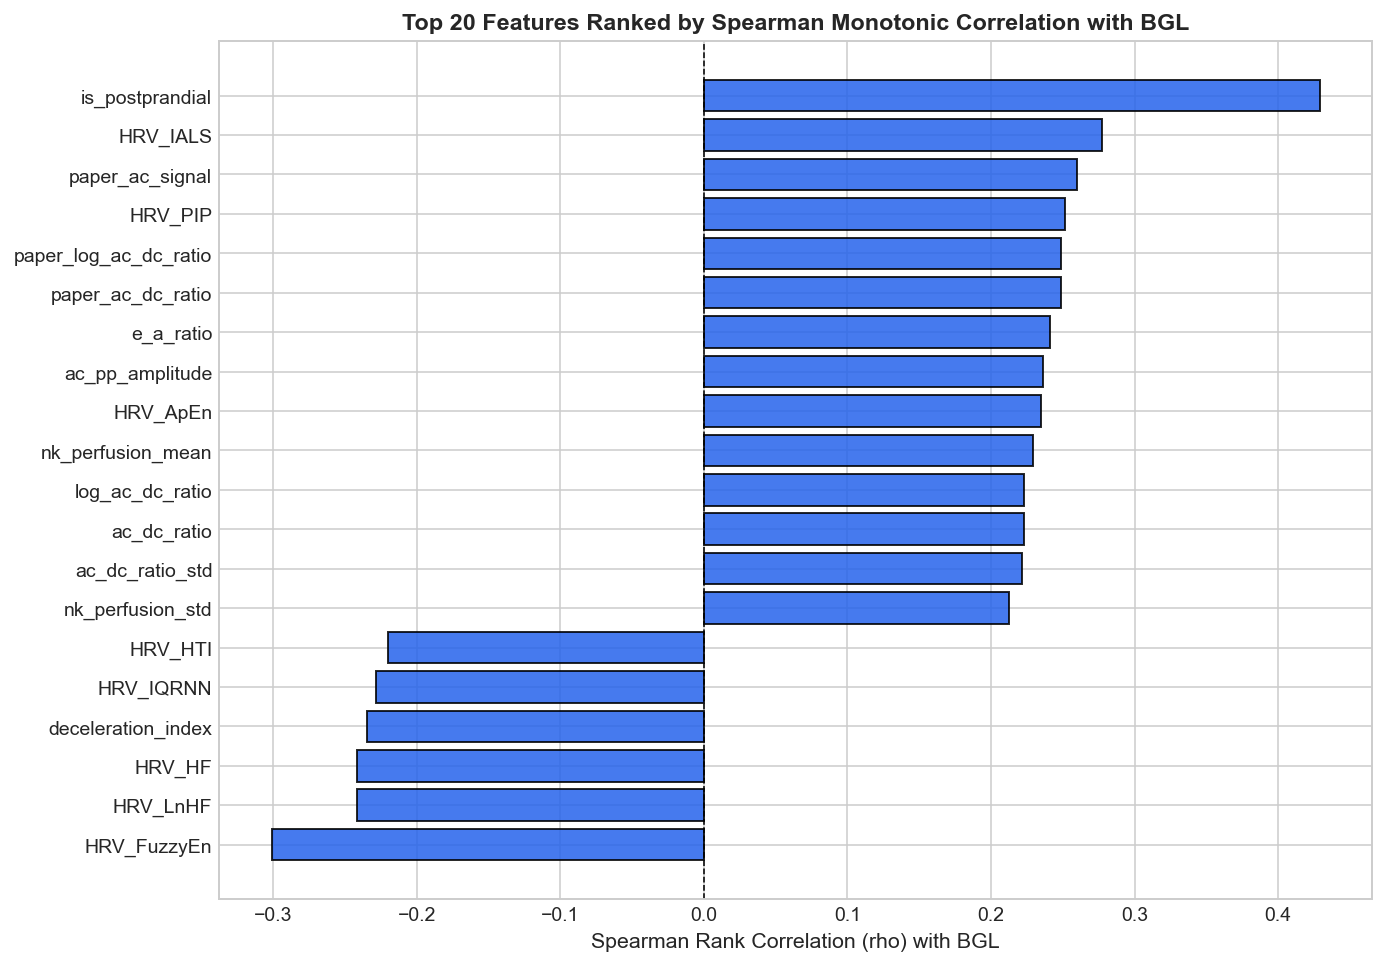

In [32]:
# ── Calculate Dataset-Wide Correlations with bgl_mgdl ──
y_full = df_windowed_features['bgl_mgdl'].values
corr_records = []
for feat in ALL_CANDIDATE_FEATURES:
    vals = df_windowed_features[feat].values
    valid_mask = ~np.isnan(vals) & ~np.isnan(y_full)
    if np.sum(valid_mask) > 5 and np.std(vals[valid_mask]) > 1e-9:
        r_p, p_p = pearsonr(vals[valid_mask], y_full[valid_mask])
        r_s, p_s = spearmanr(vals[valid_mask], y_full[valid_mask])
        if feat in DEMOGRAPHIC_METADATA_COLS: cat = 'Demographic'
        elif feat in AC_DC_PERFUSION_FEATURES: cat = 'AC/DC Perfusion'
        elif feat in PPG_MORPHOLOGY_FEATURES: cat = 'PPG Morphology'
        elif feat in VPG_APG_DERIVATIVE_FEATURES: cat = 'APG Derivative'
        else: cat = 'HRV/Spectral'
        corr_records.append({
            'Feature': feat, 'Category': cat, 'Pearson r': r_p, 'Pearson p-val': p_p,
            'Spearman rho': r_s, 'Spearman p-val': p_s, 'Abs Spearman rho': abs(r_s)
        })

corr_df = pd.DataFrame(corr_records).sort_values(by='Abs Spearman rho', ascending=False).reset_index(drop=True)
print('=== Top 25 Features Ranked by Spearman Monotonic Correlation (rho) ===')
display(corr_df.head(25))

plt.figure(figsize=(10, 7))
top_plot_df = corr_df.head(20).sort_values(by='Spearman rho', ascending=True)
plt.barh(top_plot_df['Feature'], top_plot_df['Spearman rho'], color='#2563eb', alpha=0.85, edgecolor='k')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Spearman Rank Correlation (rho) with BGL', fontsize=11)
plt.title('Top 20 Features Ranked by Spearman Monotonic Correlation with BGL', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## ⚙️ Model Fitting Feature Pool Configuration

You can easily modify `SELECTED_FEATURE_POOL` below to test specific feature subsets (e.g. Demographics + AC/DC + APG) or leave it as `ALL_CANDIDATE_FEATURES` to allow automated fold-level feature selection.


In [33]:
# ==========================================
# CONFIGURABLE ACTIVE FEATURE SELECTION POOL
# ==========================================
INCLUDE_DEMOGRAPHICS = True  # Controls inclusion of eligible demographic feature ('is_postprandial')

if INCLUDE_DEMOGRAPHICS:
    SELECTED_FEATURE_POOL = ALL_CANDIDATE_FEATURES.copy()
else:
    SELECTED_FEATURE_POOL = [f for f in ALL_CANDIDATE_FEATURES if f not in DEMOGRAPHIC_METADATA_COLS]

print(f'✓ Active Feature Candidate Pool size for Cross-Validation: {len(SELECTED_FEATURE_POOL)} features')
print(f'✓ Eligible Demographic Feature Included (is_postprandial): {INCLUDE_DEMOGRAPHICS}')
print(f'✓ Excluded Static Patient Descriptors: {PATIENT_METADATA_COLS}')


✓ Active Feature Candidate Pool size for Cross-Validation: 124 features
✓ Eligible Demographic Feature Included (is_postprandial): True
✓ Excluded Static Patient Descriptors: ['age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm']


## 🛡️ Strict Zero-Leakage Grouped Cross-Validation (`GroupKFold` & `LOGOCV`)

To guarantee **100% Zero Data Leakage** under windowing:
- All sub-windows belonging to the same participant (`participant_id`) are kept **100% strictly in either Train or Test fold**.
- Fold-level `SimpleImputer` and fold-level feature selection (`select_features_on_fold_train`) are computed **strictly inside each training fold**.


In [36]:
# ==============================================================================
# ZERO-LEAKAGE FOLD-LEVEL FEATURE SELECTION & REGRESSION SUITE
# ==============================================================================
def select_features_on_fold_train(X_tr_df, y_tr, feature_pool, max_features=15, collinear_threshold=0.85, method='spearman'):
    imp = SimpleImputer(strategy='mean')
    X_tr_imp_vals = imp.fit_transform(X_tr_df[feature_pool])
    X_tr_imp = pd.DataFrame(X_tr_imp_vals, columns=feature_pool, index=X_tr_df.index)
    
    corrs = X_tr_imp.apply(lambda col: col.corr(pd.Series(y_tr, index=X_tr_df.index), method=method))
    sorted_corrs = corrs.abs().sort_values(ascending=False)
    candidate_feats = sorted_corrs.head(30).index.tolist()
    
    corr_matrix = X_tr_imp[candidate_feats].corr(method=method).abs()
    to_drop = set()
    for i in range(len(candidate_feats)):
        col_i = candidate_feats[i]
        if col_i in to_drop: continue
        for j in range(i + 1, len(candidate_feats)):
            col_j = candidate_feats[j]
            if col_j in to_drop: continue
            if corr_matrix.loc[col_i, col_j] > collinear_threshold:
                if abs(corrs[col_i]) >= abs(corrs[col_j]):
                    to_drop.add(col_j)
                else:
                    to_drop.add(col_i)
    return [f for f in candidate_feats if f not in to_drop][:max_features]

X_full_df = df_windowed_features[SELECTED_FEATURE_POOL].copy()
X_full_df = X_full_df.replace([np.inf, -np.inf], np.nan)
y = df_windowed_features['bgl_mgdl'].values
groups = df_windowed_features['participant_id'].values

gkf = GroupKFold(n_splits=5)
logo = LeaveOneGroupOut()

print("=== Pre-extracting Zero-Leakage Fold Feature Subsets (Spearman Rank Selection) ===")
gkf_folds_data = []
for train_idx, val_idx in gkf.split(X_full_df, y, groups):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, SELECTED_FEATURE_POOL, method='spearman')
    gkf_folds_data.append((train_idx, val_idx, fold_feats))

logo_folds_data = []
for train_idx, val_idx in logo.split(X_full_df, y, groups):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, SELECTED_FEATURE_POOL, method='spearman')
    logo_folds_data.append((train_idx, val_idx, fold_feats))

print(f"✓ Prepared {len(gkf_folds_data)} GroupKFold splits & {len(logo_folds_data)} LOGOCV Subject splits.")

models = {
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42)
}
if has_catboost:
    models['CatBoost'] = cb.CatBoostRegressor(verbose=0, random_state=42)
if has_xgboost:
    models['XGBoost'] = xgb.XGBRegressor(random_state=42)

strict_results = []
for model_name, model in models.items():
    g_maes, g_rmses, g_r2s = [], [], []
    for train_idx, val_idx, fold_feats in gkf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        if isinstance(model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        g_maes.append(mean_absolute_error(y_va, preds))
        g_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        g_r2s.append(r2_score(y_va, preds))

    logo_preds = np.zeros(len(y))
    for train_idx, val_idx, fold_feats in logo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        if isinstance(model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        model.fit(X_tr_imp, y_tr)
        logo_preds[val_idx] = model.predict(X_va_imp)

    logo_mae = mean_absolute_error(y, logo_preds)
    logo_rmse = np.sqrt(mean_squared_error(y, logo_preds))
    logo_r2 = r2_score(y, logo_preds)

    strict_results.append({
        'Algorithm': model_name,
        '5F-GroupKF MAE': f'{np.mean(g_maes):.2f}',
        '5F-GroupKF RMSE': f'{np.mean(g_rmses):.2f}',
        '5F-GroupKF R^2': f'{np.mean(g_r2s):.3f}',
        'LOGOCV MAE': f'{logo_mae:.2f}',
        'LOGOCV RMSE': f'{logo_rmse:.2f}',
        'LOGOCV R^2': f'{logo_r2:.3f}'
    })

summary_df = pd.DataFrame(strict_results)
print()
print("=== Strict Zero-Leakage Subject-Grouped Cross-Validation Evaluation Summary ===")
display(summary_df)


=== Pre-extracting Zero-Leakage Fold Feature Subsets (Spearman Rank Selection) ===


✓ Prepared 5 GroupKFold splits & 84 LOGOCV Subject splits.

=== Strict Zero-Leakage Subject-Grouped Cross-Validation Evaluation Summary ===


,Algorithm,5F-GroupKF MAE,5F-GroupKF RMSE,5F-GroupKF R^2,LOGOCV MAE,LOGOCV RMSE,LOGOCV R^2
0,Linear Regression (OLS),34.72,42.28,0.141,35.27,43.71,0.131
1,Ridge Regression,34.65,42.20,0.144,35.23,43.65,0.134
2,Lasso Regression,34.56,42.10,0.148,35.10,43.51,0.139
3,ElasticNet,34.34,41.81,0.160,34.95,43.17,0.152
4,Random Forest,36.68,43.60,0.086,37.62,44.31,0.107
5,Gradient Boosting,38.06,46.47,-0.047,38.56,47.02,-0.005
6,Extra Trees,35.66,44.33,0.046,36.55,45.02,0.078
7,CatBoost,35.95,44.35,0.051,37.53,45.98,0.039
8,XGBoost,36.79,46.17,-0.033,39.68,49.46,-0.113


## 📊 Model Feature Importance & Interpretability Analysis

To understand which physiological and signal features drive blood glucose predictions across unseen participants:
1. **Selection Stability**: We track how frequently each feature is selected across all 84 Leave-One-Group-Out (LOGOCV) folds.
2. **Random Forest MDI Importance**: We compute the mean impurity reduction (Gini/MSE importance) assigned to each feature.
3. **Ridge Regression $|eta|$ Coefficients**: We examine the standardized linear effect sizes of key features.
4. **Category Impact**: We aggregate importance across feature domains (Demographics, AC/DC Perfusion, PPG Waveform Morphology, APG Derivatives, HRV Metrics).


=== TOP 15 MOST STABLE & IMPORTANT FEATURES ACROSS LOGOCV FOLDS ===


,Feature,Category,LOGOCV Fold Frequency,Mean RF Importance,Mean Ridge |Coef|
0,is_postprandial,Demographic,84/84 (100.0%),0.238392,19.414079
1,HRV_FuzzyEn,HRV/Spectral,84/84 (100.0%),0.099344,3.458292
2,HRV_IALS,HRV/Spectral,84/84 (100.0%),0.134378,5.550006
3,paper_ac_signal,AC/DC Perfusion,84/84 (100.0%),0.077246,0.473101
4,HRV_ApEn,HRV/Spectral,84/84 (100.0%),0.058642,0.438997
5,HRV_IQRNN,HRV/Spectral,84/84 (100.0%),0.053121,3.032756
6,e_a_ratio,APG Derivative,81/84 (96.4%),0.112903,4.608555
7,HRV_HTI,HRV/Spectral,79/84 (94.0%),0.045345,3.163850
8,ac_pp_amplitude,AC/DC Perfusion,79/84 (94.0%),0.081935,2.061996
9,HRV_LnHF,HRV/Spectral,71/84 (84.5%),0.098259,5.139691


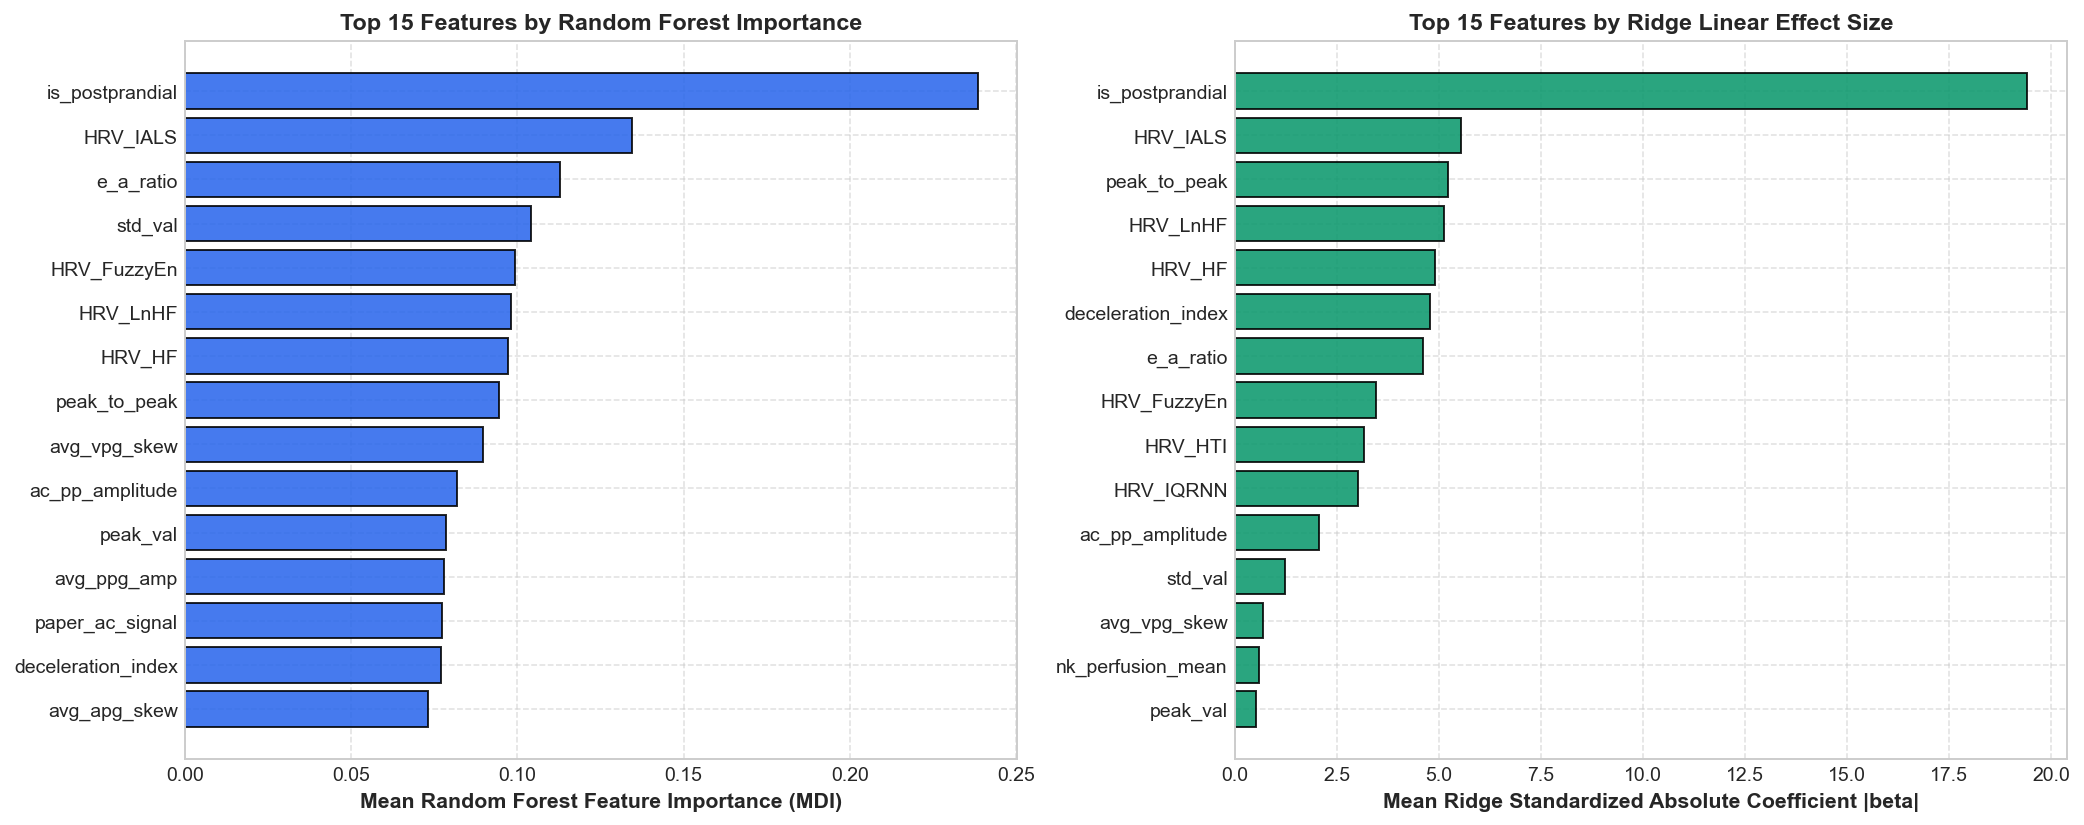


=== FEATURE DOMAIN SELECTION & IMPORTANCE CONTRIBUTION SUMMARY ===


,Category,Total_Selected_Features,Total_Selections,Avg_RF_Importance
3,HRV/Spectral,7,498,0.083751
0,AC/DC Perfusion,3,167,0.076748
1,APG Derivative,4,87,0.088172
2,Demographic,1,84,0.238392
4,PPG Morphology,4,4,0.088833


In [17]:
# ==============================================================================
# MODEL FEATURE IMPORTANCE & SELECTION STABILITY ANALYSIS
# ==============================================================================
from sklearn.preprocessing import StandardScaler

# 1. Track Feature Selection Frequency & RF / Ridge Importances across LOGOCV folds
rf_imp_acc = {}
ridge_coef_acc = {}
selection_counts = {}
num_logo_folds = len(logo_folds_data)

for train_idx, val_idx, fold_feats in logo_folds_data:
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    imp = SimpleImputer(strategy='mean')
    X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
    
    # Fit RF on fold train
    rf_fold = RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42)
    rf_fold.fit(X_tr_imp, y_tr)
    
    # Fit Ridge on standardized fold train
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_imp)
    ridge_fold = Ridge()
    ridge_fold.fit(X_tr_scaled, y_tr)
    
    for feat, rf_val, r_val in zip(fold_feats, rf_fold.feature_importances_, np.abs(ridge_fold.coef_)):
        selection_counts[feat] = selection_counts.get(feat, 0) + 1
        rf_imp_acc[feat]       = rf_imp_acc.get(feat, 0.0) + rf_val
        ridge_coef_acc[feat]   = ridge_coef_acc.get(feat, 0.0) + r_val

# 2. Build Summary Table
feat_imp_rows = []
for feat, count in selection_counts.items():
    rf_mean = rf_imp_acc[feat] / count
    ridge_mean = ridge_coef_acc[feat] / count
    
    if feat in DEMOGRAPHIC_METADATA_COLS: cat = 'Demographic'
    elif feat in AC_DC_PERFUSION_FEATURES: cat = 'AC/DC Perfusion'
    elif feat in PPG_MORPHOLOGY_FEATURES: cat = 'PPG Morphology'
    elif feat in VPG_APG_DERIVATIVE_FEATURES: cat = 'APG Derivative'
    else: cat = 'HRV/Spectral'
    
    feat_imp_rows.append({
        'Feature': feat,
        'Category': cat,
        'LOGOCV Fold Frequency': f'{count}/{num_logo_folds} ({count/num_logo_folds*100:.1f}%)',
        'Selection Count': count,
        'Mean RF Importance': rf_mean,
        'Mean Ridge |Coef|': ridge_mean
    })

df_importance_summary = pd.DataFrame(feat_imp_rows).sort_values(by='Selection Count', ascending=False).reset_index(drop=True)
print('=== TOP 15 MOST STABLE & IMPORTANT FEATURES ACROSS LOGOCV FOLDS ===')
display(df_importance_summary.head(15)[['Feature', 'Category', 'LOGOCV Fold Frequency', 'Mean RF Importance', 'Mean Ridge |Coef|']])

# 3. Visualizations: Top Features & Domain Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Top 15 Features by RF Importance
top_rf_df = df_importance_summary.sort_values(by='Mean RF Importance', ascending=True).tail(15)
axes[0].barh(top_rf_df['Feature'], top_rf_df['Mean RF Importance'], color='#2563eb', alpha=0.85, edgecolor='k')
axes[0].set_xlabel('Mean Random Forest Feature Importance (MDI)', fontsize=11, fontweight='bold')
axes[0].set_title('Top 15 Features by Random Forest Importance', fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot B: Top 15 Features by Ridge |Coef|
top_ridge_df = df_importance_summary.sort_values(by='Mean Ridge |Coef|', ascending=True).tail(15)
axes[1].barh(top_ridge_df['Feature'], top_ridge_df['Mean Ridge |Coef|'], color='#059669', alpha=0.85, edgecolor='k')
axes[1].set_xlabel('Mean Ridge Standardized Absolute Coefficient |beta|', fontsize=11, fontweight='bold')
axes[1].set_title('Top 15 Features by Ridge Linear Effect Size', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. Feature Domain Contribution Summary
domain_summary = df_importance_summary.groupby('Category').agg(
    Total_Selected_Features=('Feature', 'count'),
    Total_Selections=('Selection Count', 'sum'),
    Avg_RF_Importance=('Mean RF Importance', 'mean')
).reset_index().sort_values(by='Total_Selections', ascending=False)

print('\n=== FEATURE DOMAIN SELECTION & IMPORTANCE CONTRIBUTION SUMMARY ===')
display(domain_summary)


## 🩺 Logistic Regression Classification (Hyperglycemia Risk Thresholding)

In addition to continuous BGL estimation, we evaluate **Logistic Regression** for clinical risk classification:
- **Target Condition**: Hyperglycemia threshold ($	ext{BGL} \ge 180\text{ mg/dL}$).
- **Validation Strategy**: Subject-Unseen Leave-One-Group-Out Cross-Validation (`LOGOCV`).
- **Metrics Evaluated**: Accuracy, ROC-AUC, Sensitivity (Recall), Specificity, and F1-Score.


  LOGISTIC REGRESSION LOGOCV HYPERGLYCEMIA CLASSIFICATION
  Target Condition:           BGL >= 180 mg/dL
  LOGOCV Accuracy:            76.44%
  LOGOCV ROC-AUC Score:       0.750
  LOGOCV Sensitivity (Recall):42.31%
  LOGOCV F1-Score:            0.494


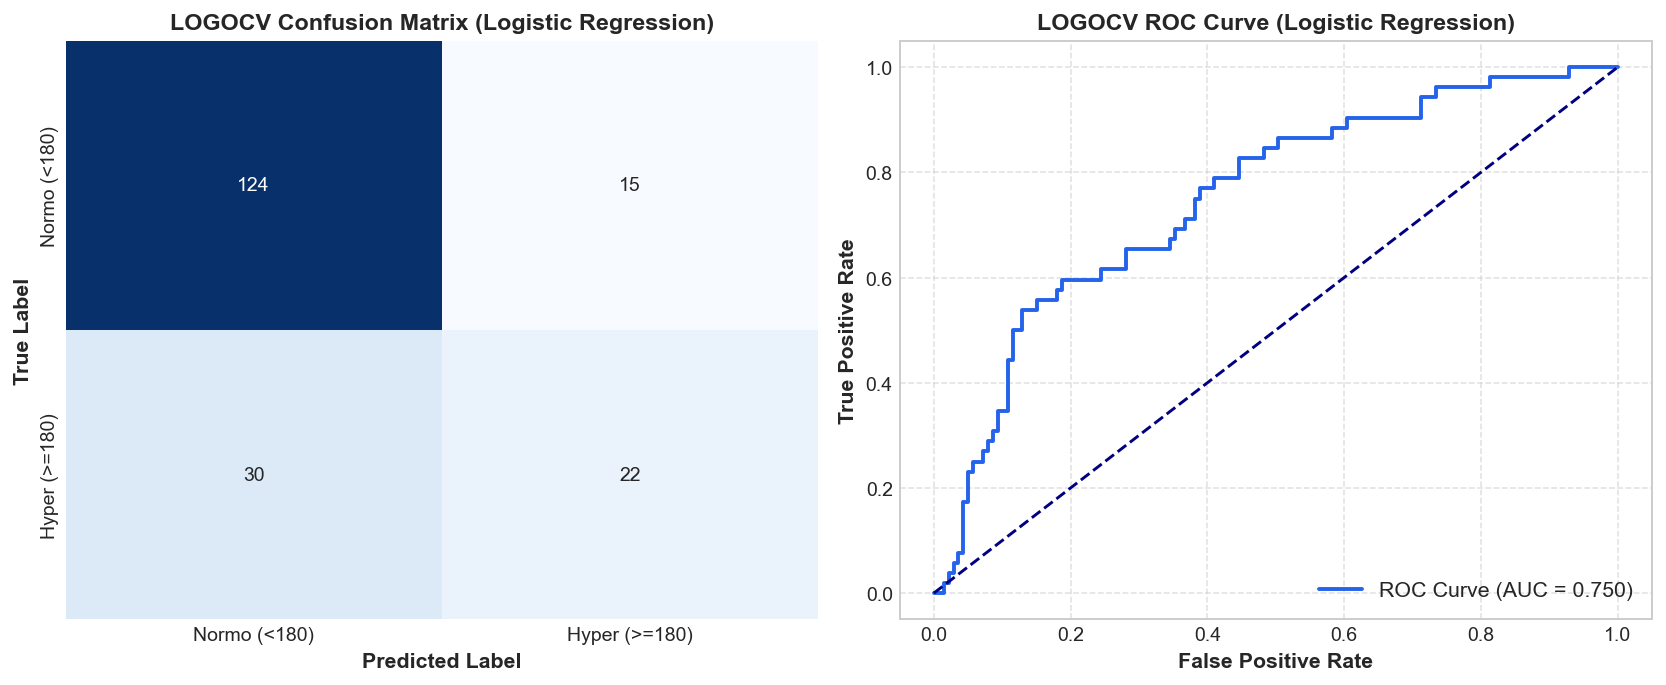

In [26]:
# ==============================================================================
# LOGISTIC REGRESSION HYPERGLYCEMIA RISK CLASSIFICATION (LOGOCV)
# ==============================================================================
y_binary = (y >= 180).astype(int)
clf_preds = np.zeros(len(y))
clf_probs = np.zeros(len(y))

for train_idx, val_idx, fold_feats in logo_folds_data:
    X_tr_df, y_tr_bin = X_full_df.iloc[train_idx].copy(), y_binary[train_idx]
    X_va_df = X_full_df.iloc[val_idx].copy()
    imp = SimpleImputer(strategy='mean')
    X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
    X_va_imp = imp.transform(X_va_df[fold_feats])
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_imp)
    X_va_scaled = scaler.transform(X_va_imp)
    
    clf = LogisticRegression(random_state=42)
    clf.fit(X_tr_scaled, y_tr_bin)
    clf_preds[val_idx] = clf.predict(X_va_scaled)
    if hasattr(clf, 'predict_proba'):
        clf_probs[val_idx] = clf.predict_proba(X_va_scaled)[:, 1]

acc = accuracy_score(y_binary, clf_preds)
auc = roc_auc_score(y_binary, clf_probs)
rec = recall_score(y_binary, clf_preds)
f1 = f1_score(y_binary, clf_preds)
cm = confusion_matrix(y_binary, clf_preds)

print('=================================================================')
print('  LOGISTIC REGRESSION LOGOCV HYPERGLYCEMIA CLASSIFICATION')
print('=================================================================')
print(f'  Target Condition:           BGL >= 180 mg/dL')
print(f'  LOGOCV Accuracy:            {acc*100:.2f}%')
print(f'  LOGOCV ROC-AUC Score:       {auc:.3f}')
print(f'  LOGOCV Sensitivity (Recall):{rec*100:.2f}%')
print(f'  LOGOCV F1-Score:            {f1:.3f}')
print('=================================================================')

# Confusion Matrix & ROC Curve Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Normo (<180)', 'Hyper (>=180)'],
            yticklabels=['Normo (<180)', 'Hyper (>=180)'])
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_title('LOGOCV Confusion Matrix (Logistic Regression)', fontsize=12, fontweight='bold')

fpr, tpr, _ = roc_curve(y_binary, clf_probs)
axes[1].plot(fpr, tpr, color='#2563eb', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
axes[1].set_title('LOGOCV ROC Curve (Logistic Regression)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
